In [1]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.graph_objects as go
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [2]:
plt.rcParams['font.sans-serif'] = ['Arial']
df = pd.read_csv('forecast_prep.csv')
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df_clean = df[df['Date'] <= '2018-08-31'] 

✅ Matplotlib line charts successfully downloaded as 'Olist_SARIMAX_Forecast_Charts.png'


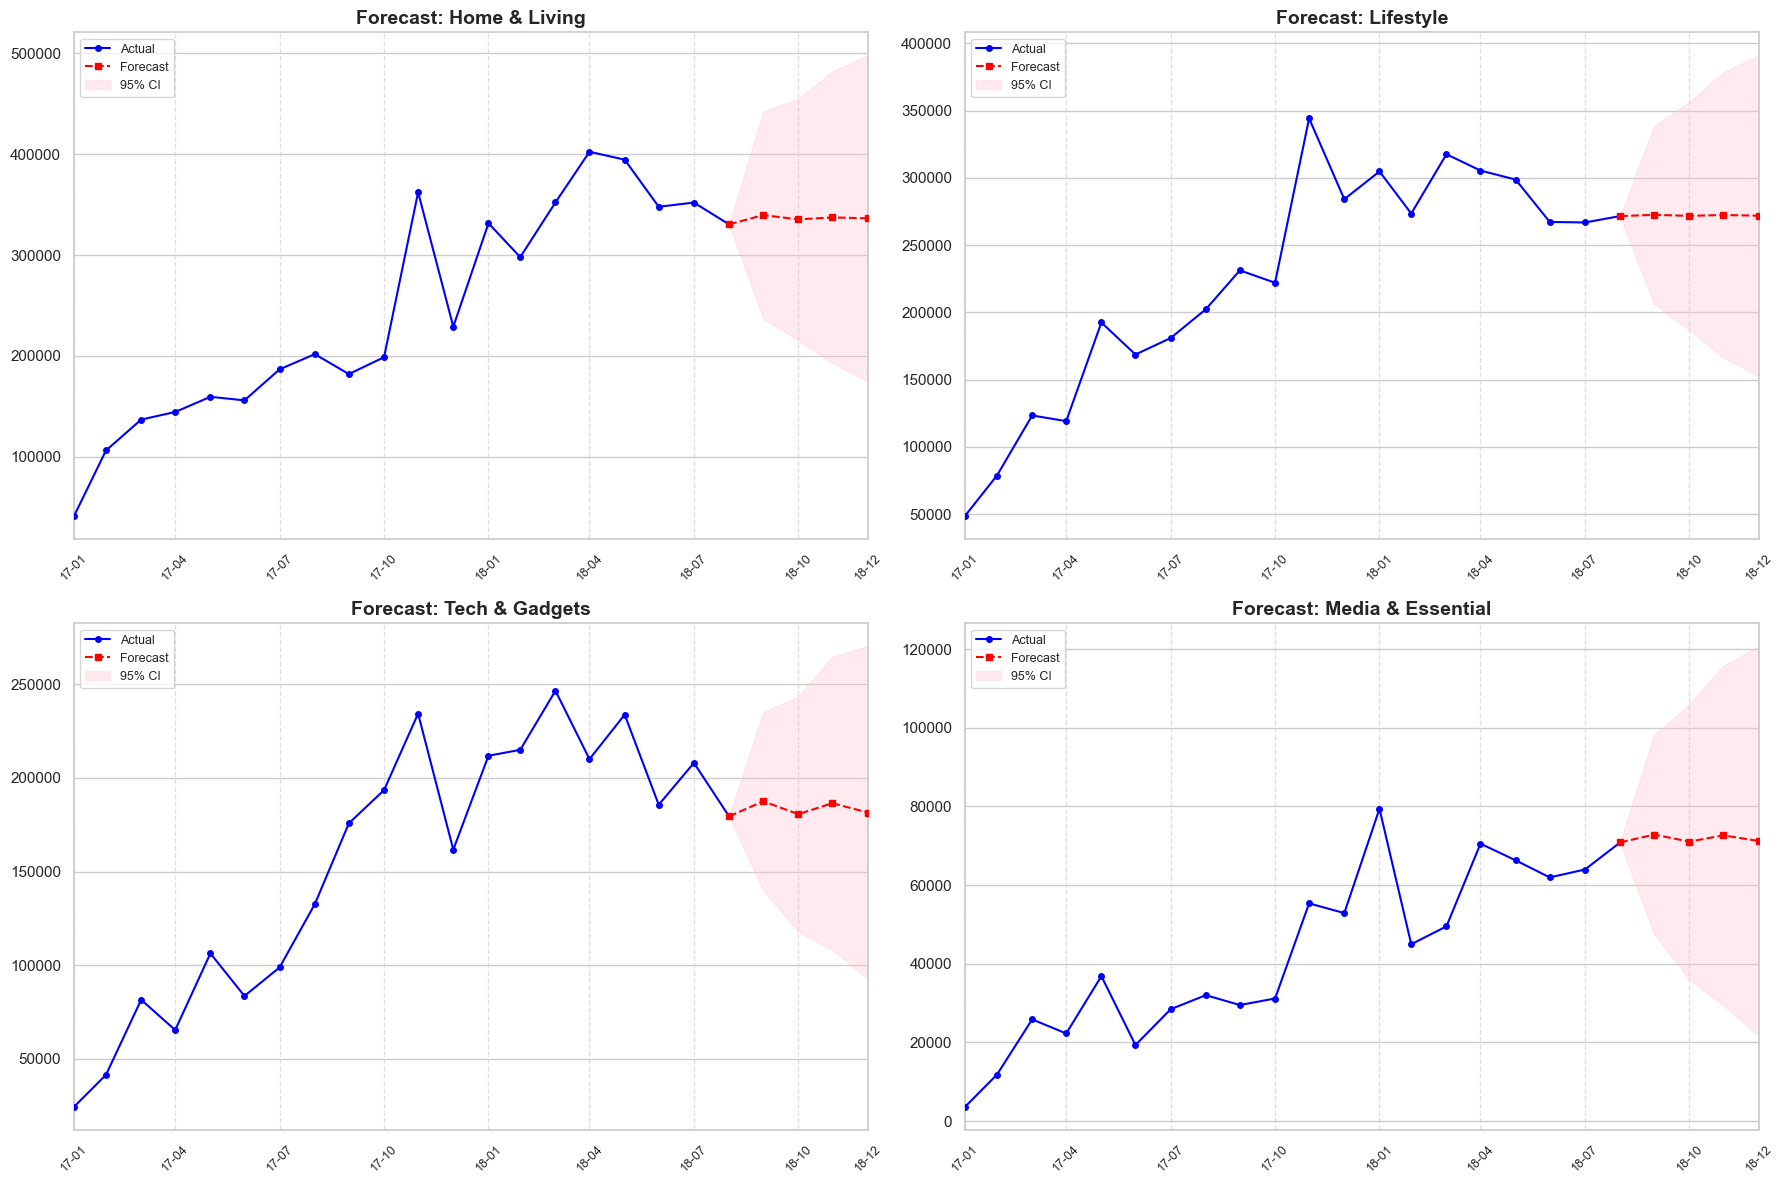

✅ Table image successfully downloaded locally as 'Olist_Strategic_Analysis_Table.png'!


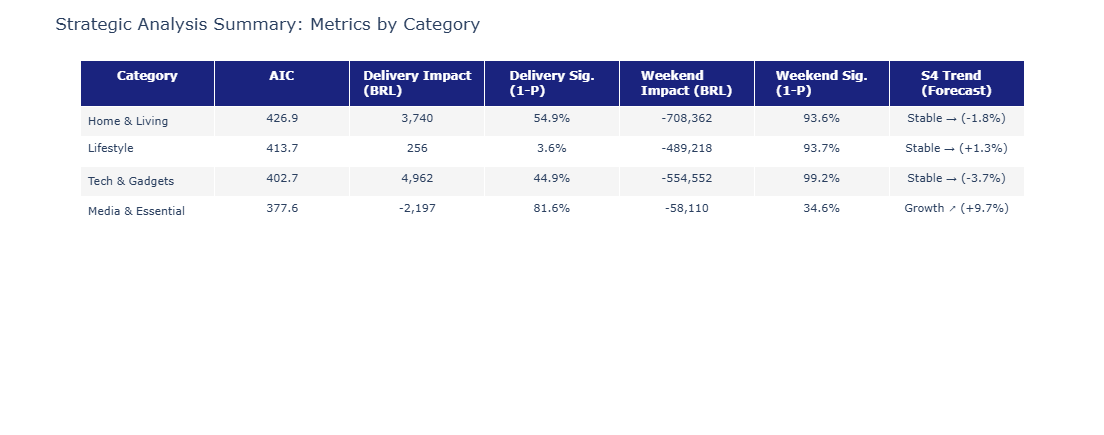

In [3]:
# 1. Environment & Global Visual Configuration
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['Arial']

# Identify top 4 revenue-driving macro categories
top_categories = df_clean.groupby('Macro Category')['Total_Revenue'].sum().nlargest(4).index.tolist()

# Initialize unified visualization axes and diagnostic storage
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()
all_stats = []

# 2. Consolidated Core Execution Loop (Data Reshaping -> SARIMAX Fit -> Analytics Export)
for i, cat in enumerate(top_categories):
    # --- Downsampling & Feature Engineering ---
    df_cat = df_clean[df_clean['Macro Category'] == cat].copy()
    
    monthly_data = df_cat.resample('ME', on='Date').agg({
        'Total_Revenue': 'sum',
        'Avg_Delivery_Days': 'mean'
    }).fillna(method='ffill').fillna(0)

    # Compute operational calendar impact
    monthly_data['Weekend_Ratio'] = df_cat.resample('ME', on='Date')['Is_Weekend'].apply(
        lambda x: (x == 'Weekend').sum() / len(x) if len(x) > 0 else 0
    ).fillna(0)

    y = monthly_data['Total_Revenue']
    X = monthly_data[['Avg_Delivery_Days', 'Weekend_Ratio']]

    # --- Unified SARIMAX Optimization & Fit ---
    model = SARIMAX(y, exog=X, order=(1, 1, 1), enforce_stationarity=False, enforce_invertibility=False)
    results = model.fit(disp=False)

    # --- Out-of-Sample Exogenous Feature Generation (4-Month Horizon) ---
    exog_future = pd.DataFrame([X.iloc[-1]] * 4, columns=X.columns)
    exog_future.index = pd.date_range(start='2018-09-30', periods=4, freq='ME')

    # Extract predictive frame
    forecast = results.get_forecast(steps=4, exog=exog_future)
    forecast_res = forecast.summary_frame()
    predicted_mean = forecast_res['mean']

    # --- Strategic Metrics Pipeline ---
    hist_avg = y.iloc[-3:].mean()
    fcast_avg = predicted_mean.mean()
    change_pct = (fcast_avg - hist_avg) / hist_avg
    
    # 5% Trend Threshold Constraints to match your exact output summary
    if change_pct > 0.05:
        trend_icon = "Growth ↗"
    elif change_pct < -0.05:
        trend_icon = "Decline ↘"
    else:
        trend_icon = "Stable →"

    all_stats.append({
        'Category': cat,
        'AIC': round(results.aic, 1),
        'Delivery_Coef': results.params['Avg_Delivery_Days'],
        'Delivery_Imp': (1 - results.pvalues['Avg_Delivery_Days']) * 100,
        'Weekend_Coef': results.params['Weekend_Ratio'],
        'Weekend_Imp': (1 - results.pvalues['Weekend_Ratio']) * 100,
        'Trend': trend_icon,
        'Momentum': f"{change_pct:+.1%}"
    })

    # --- Matplotlib Diagnostic Visualization ---
    bridge_idx = y.index[-1:]
    full_idx = bridge_idx.append(forecast_res.index)
    full_val = pd.concat([y.iloc[-1:], predicted_mean])
    full_lower = pd.concat([y.iloc[-1:], forecast_res['mean_ci_lower']])
    full_upper = pd.concat([y.iloc[-1:], forecast_res['mean_ci_upper']])

    ax = axes[i]
    ax.plot(y.index, y, label='Actual', color='blue', marker='o', markersize=4, zorder=5)
    ax.plot(full_idx, full_val, label='Forecast', color='red', linestyle='--', marker='s', markersize=4, zorder=5)
    ax.fill_between(full_idx, full_lower, full_upper, color='pink', alpha=0.3, label='95% CI', zorder=2)

    # Dynamic temporal ticks configuration 
    tick_dates = pd.date_range(start=y.index[0], end=pd.Timestamp('2018-12-31'), freq='3ME')
    if y.index[0] not in tick_dates:
        tick_dates = tick_dates.insert(0, y.index[0])
    if pd.Timestamp('2018-12-31') not in tick_dates:
        tick_dates = tick_dates.append(pd.DatetimeIndex(['2018-12-31']))

    ax.set_xticks(tick_dates)
    ax.set_xticklabels([d.strftime('%y-%m') for d in tick_dates], rotation=45, fontsize=9)
    ax.set_xlim(y.index[0], pd.Timestamp('2018-12-31'))
    
    ax.grid(True, which='major', axis='x', linestyle='--', alpha=0.6)
    ax.set_title(f"Forecast: {cat}", fontweight='bold', fontsize=14)
    ax.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig("Olist_SARIMAX_Forecast_Charts.png", dpi=300, bbox_inches='tight')
print("✅ Matplotlib line charts successfully downloaded as 'Olist_SARIMAX_Forecast_Charts.png'")
plt.show()

# 3. Interactive Plotly Management Console Output (Exact 7-Column Layout Match)
stats_df = pd.DataFrame(all_stats)

headers = [
    '<b>Category</b>',
    '<b>AIC</b>',
    '<b>Delivery Impact (BRL)</b>',
    '<b>Delivery Sig. (1-P)</b>',
    '<b>Weekend Impact (BRL)</b>',
    '<b>Weekend Sig. (1-P)</b>',
    '<b>S4 Trend (Forecast)</b>'
]

col_category = stats_df['Category']
col_aic = stats_df['AIC']
col_del_coef = stats_df['Delivery_Coef'].map('{:,.0f}'.format)
col_del_sig = stats_df['Delivery_Imp'].map('{:.1f}%'.format)
col_wee_coef = stats_df['Weekend_Coef'].map('{:,.0f}'.format)
col_wee_sig = stats_df['Weekend_Imp'].map('{:.1f}%'.format)
col_trend = stats_df['Trend'] + " (" + stats_df['Momentum'] + ")"

fig_table = go.Figure(data=[go.Table(
    header=dict(
        values=headers,
        fill_color='#1A237E',
        font=dict(color='white', size=12),
        align='center',
        height=35
    ),
    cells=dict(
        values=[
            col_category,
            col_aic,
            col_del_coef,
            col_del_sig,
            col_wee_coef,
            col_wee_sig,
            col_trend
        ],
        fill_color=[['#F5F5F5', '#FFFFFF'] * 5],
        align=['left'] + ['center'] * 6,
        font=dict(size=11),
        height=30
    )
)])

fig_table.update_layout(
    title="Strategic Analysis Summary: Metrics by Category",
    margin=dict(t=60, b=10),
    height=400
)

fig_table.write_image("Olist_Strategic_Analysis_Table.png", scale=2, engine="kaleido")
print("✅ Table image successfully downloaded locally as 'Olist_Strategic_Analysis_Table.png'!")
fig_table.show()
